In [90]:
import numpy as np 
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [91]:
df = pd.read_csv('used_car_listings.csv',usecols=[9,10,11])

In [92]:
df.head(2)

,mileage,price,condition
0,46134,19919.0,good
1,16109,19480.0,good


In [93]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')

si.fit_transform(y_train.values.reshape(-1,1))

array([['good'],
       ['excellent'],
       ['good'],
       ...,
       ['fair'],
       ['good'],
       ['good']], dtype=object)

In [94]:
df['condition'].fillna(df['condition'].value_counts().index[0],inplace=True)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_3652\2052693466.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['condition'].fillna(df['condition'].value_counts().index[0],inplace=True)


In [95]:
df.isnull().sum()

mileage      0
price        0
condition    0
dtype: int64

In [96]:
x = df.drop(columns='condition')
y = df['condition']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# PDF & QQPlot Before Function_Transformer

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_3652\88049864.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['mileage'])


Text(0.5, 1.0, 'Mileage QQPlot')

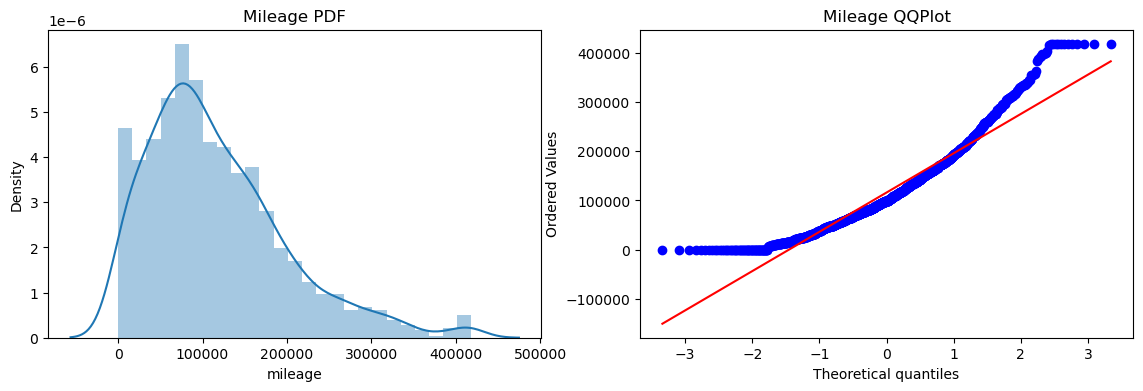

In [97]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.distplot(x_train['mileage'])
plt.title('Mileage PDF')

plt.subplot(122)
stats.probplot(x_train['mileage'], dist="norm", plot=plt)
plt.title('Mileage QQPlot')

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_3652\244313230.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['price'])


Text(0.5, 1.0, 'Mileage QQPlot')

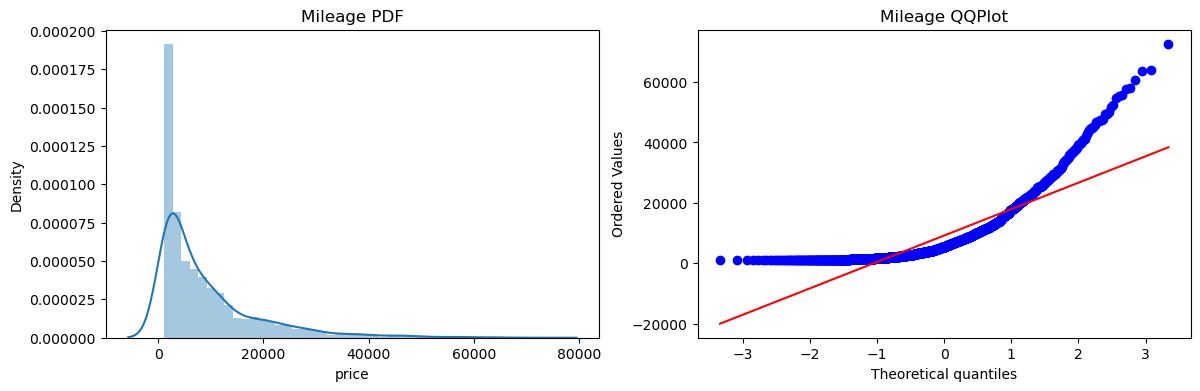

In [98]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.distplot(x_train['price'])
plt.title('Mileage PDF')

plt.subplot(122)
stats.probplot(x_train['price'], dist="norm", plot=plt)
plt.title('Mileage QQPlot')

# Function_Transformer

In [99]:
trf = ColumnTransformer([
    ('log',FunctionTransformer(func=np.log1p),[1]),
    ('sqrt',FunctionTransformer(func=np.sqrt),[0])
],remainder='passthrough')

x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

# QQplot Before & After Function_Transformer

Text(0.5, 1.0, 'QQPlot After FunctionTransformer')

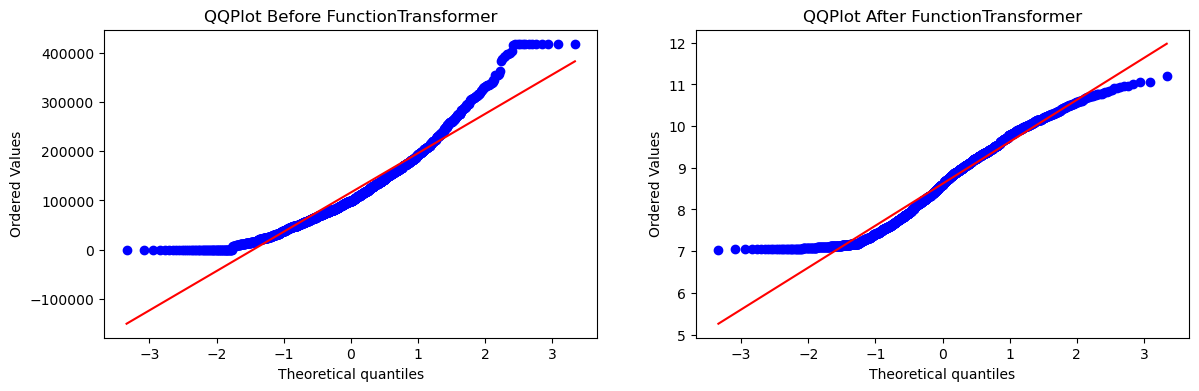

In [100]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['mileage'], dist="norm", plot=plt)
plt.title('QQPlot Before FunctionTransformer')

plt.subplot(122)
stats.probplot(x_train_transformed[:,0], dist="norm", plot=plt)
plt.title('QQPlot After FunctionTransformer')

Text(0.5, 1.0, 'QQPlot After FunctionTransformer')

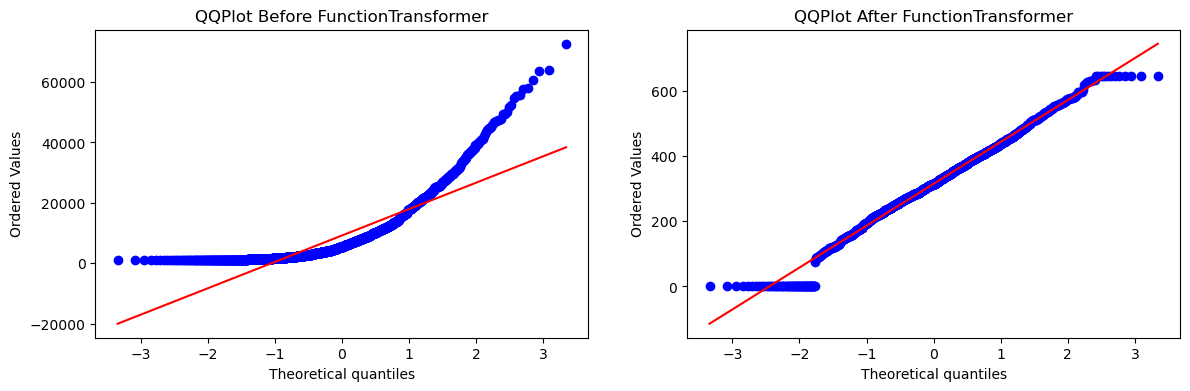

In [101]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['price'], dist="norm", plot=plt)
plt.title('QQPlot Before FunctionTransformer')

plt.subplot(122)
stats.probplot(x_train_transformed[:,1], dist="norm", plot=plt)
plt.title('QQPlot After FunctionTransformer')

# Model_Training Before Function_transformer

In [104]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("Accuracy Lr",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy Lr 0.42995169082125606
Accuracy DT 0.2608695652173913


E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [103]:
print("Accuracy Lr",np.mean(cross_val_score(clf, x, y, scoring="accuracy", cv=10)))
print("Accuracy Dt",np.mean(cross_val_score(clf2, x, y, scoring="accuracy", cv=10)))

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Accuracy Lr 0.41682847896440123
Accuracy Dt 0.29303034566858965


E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Model_Training After Function_transformer

In [105]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("Accuracy Lr",accuracy_score(y_test,y_pred))
print("Accuracy Lr",accuracy_score(y_test,y_pred2))

Accuracy Lr 0.42995169082125606
Accuracy Lr 0.24154589371980675


E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [106]:
x_transformed = trf.fit_transform(x)

print("Accuracy Lr",np.mean(cross_val_score(clf, x_transformed, y, scoring="accuracy", cv=10)))
print("Accuracy Dt",np.mean(cross_val_score(clf2, x_transformed, y, scoring="accuracy", cv=10)))

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Accuracy Lr 0.41682847896440123
Accuracy Dt 0.2964307490267811
